In [20]:
import numpy as np
import sympy as sp
from sympy.abc import t 
import matplotlib.pyplot as plt
from scipy import signal

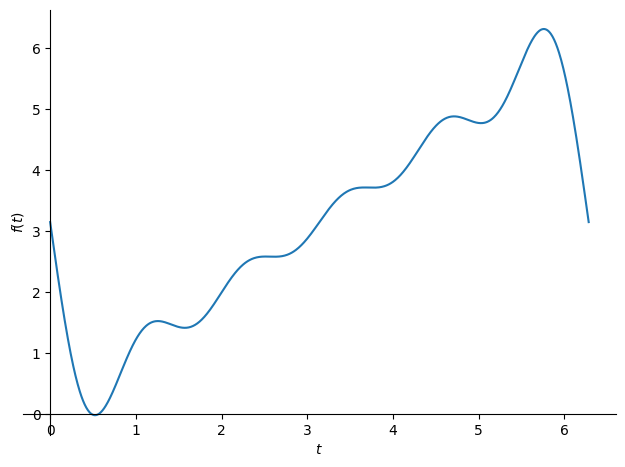

In [14]:
from sympy import fourier_series, pi, plot
from sympy.abc import t

# Define a function, e.g., f(t) = t
f = t

# Calculate Fourier series for t between -pi and pi
s = fourier_series(f, (t, 0, 2*pi))

# Truncate to the first 3 terms and plot
s_truncated = s.truncate(6)
s_truncated
plot(s_truncated, (t, 0,2*pi))
plt.show()

In [15]:
s_truncated  

-2*sin(t) - sin(2*t) - 2*sin(3*t)/3 - sin(4*t)/2 - 2*sin(5*t)/5 + pi

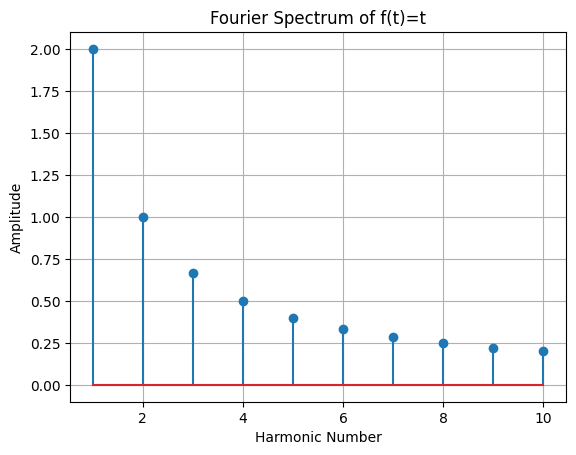

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Number of harmonics
N = 10

# Harmonic numbers
n = np.arange(1, N+1)

# Fourier amplitudes
amplitude = 2/n

# Plot spectrum
plt.stem(n, amplitude)

plt.xlabel("Harmonic Number")
plt.ylabel("Amplitude")
plt.title("Fourier Spectrum of f(t)=t")
plt.grid(True)

plt.show()

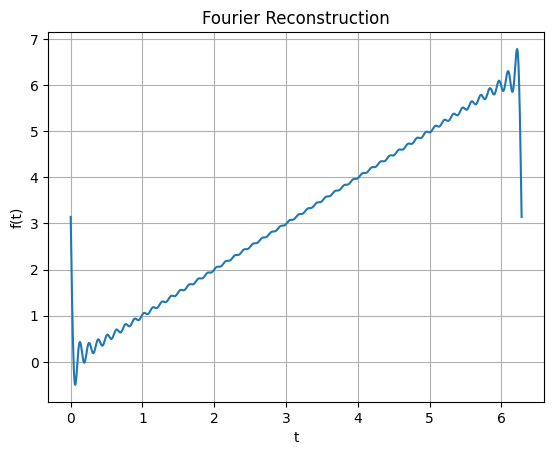

In [36]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 2*np.pi, 1000)

f = np.pi

for n in range(1, 50):
    f -= (2/n)*np.sin(n*t)

plt.plot(t, f)

plt.title("Fourier Reconstruction")
plt.xlabel("t")
plt.ylabel("f(t)")
plt.grid(True)

plt.show()

Fourier Series:


-2*sin(t) - sin(2*t) - 2*sin(3*t)/3 - sin(4*t)/2 - 2*sin(5*t)/5 - sin(6*t)/3 - 2*sin(7*t)/7 - sin(8*t)/4 - 2*sin(9*t)/9 - sin(10*t)/5 - 2*sin(11*t)/11 - sin(12*t)/6 - 2*sin(13*t)/13 - sin(14*t)/7 - 2*sin(15*t)/15 - sin(16*t)/8 - 2*sin(17*t)/17 - sin(18*t)/9 - 2*sin(19*t)/19 + pi

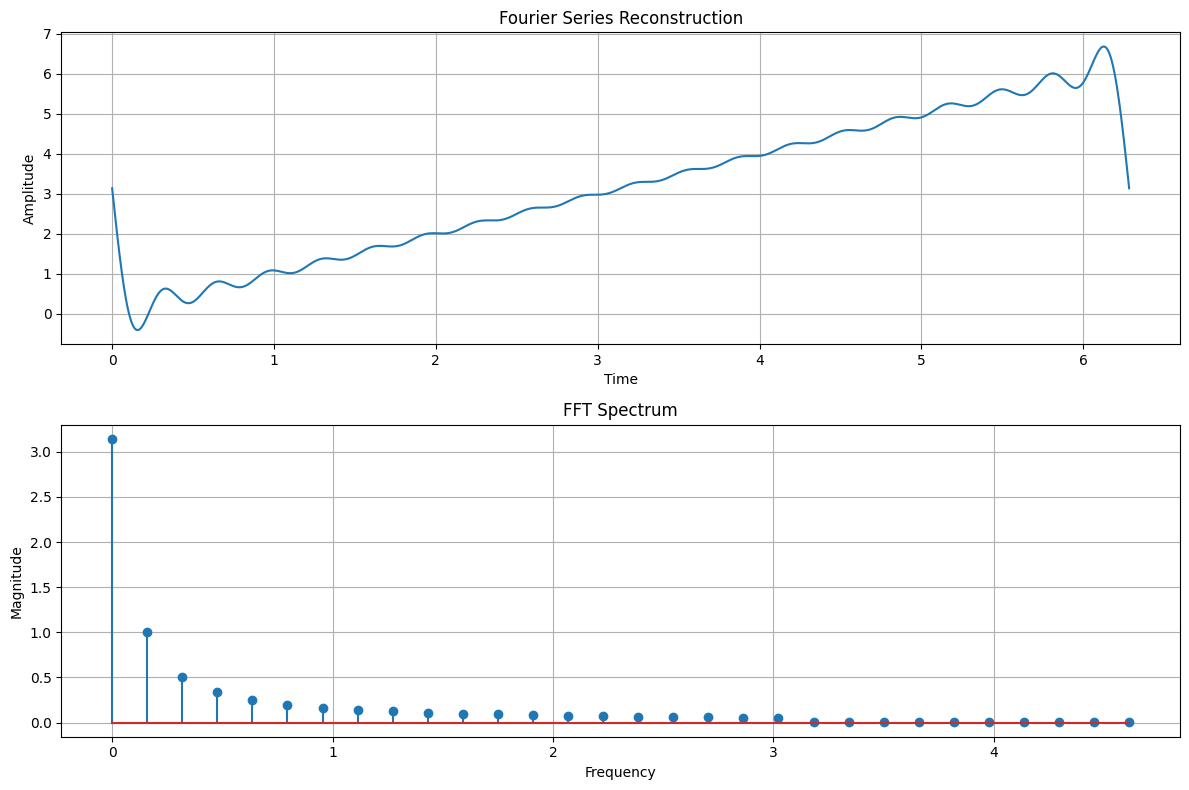

In [37]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# SYMBOLIC FOURIER SERIES
# ---------------------------------------------------

t = sp.symbols('t')

# Define function
f = t

# Fourier series on [0, 2π]
fs = sp.fourier_series(f, (t, 0, 2*sp.pi))

# Truncate series
fs_truncated = fs.truncate(20)

print("Fourier Series:")
display(sp.simplify(fs_truncated))

# ---------------------------------------------------
# LAMBDIFY
# ---------------------------------------------------

f_numeric = sp.lambdify(t, fs_truncated, modules='numpy')

# ---------------------------------------------------
# NUMERICAL EVALUATION
# ---------------------------------------------------

N = 2048
T = 2*np.pi

time = np.linspace(0, T, N)

signal = f_numeric(time)

# ---------------------------------------------------
# FFT
# ---------------------------------------------------

fft_values = np.fft.fft(signal)

freqs = np.fft.fftfreq(N, d=(time[1]-time[0]))

magnitude = np.abs(fft_values)/N

# Keep positive frequencies
positive = freqs >= 0

freqs = freqs[positive]
magnitude = magnitude[positive]

# ---------------------------------------------------
# PLOTTING
# ---------------------------------------------------

fig, ax = plt.subplots(2, 1, figsize=(12,8))

# Time-domain signal
ax[0].plot(time, signal)
ax[0].set_title("Fourier Series Reconstruction")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Amplitude")
ax[0].grid(True)

# Frequency-domain spectrum
ax[1].stem(freqs[:30], magnitude[:30])

ax[1].set_title("FFT Spectrum")
ax[1].set_xlabel("Frequency")
ax[1].set_ylabel("Magnitude")
ax[1].grid(True)

plt.tight_layout()
plt.show()